In [2]:
from games.mp import MP
from agents.fictitiousplay import FictitiousPlay
from agents.random_agent import RandomAgent
import matplotlib.pyplot as plt
import numpy as np

## Matching Pennies

Juego de suma cero con 2 agentes y 2 acciones: **H** (cara) y **T** (cruz).

Matriz de pagos de `agent_0`:

|       | H  | T  |
|-------|----|----|
| **H** | +1 | -1 |
| **T** | -1 | +1 |

Equilibrio de Nash: ambos jugadores mezclan **[0.5, 0.5]**.

## Experimento 1: FictitiousPlay vs FictitiousPlay

In [3]:
g = MP()
g.reset()

fp = dict(map(lambda agent: (agent, FictitiousPlay(game=g, agent=agent, seed=42)), g.agents))
fp

{'agent_0': <agents.fictitiousplay.FictitiousPlay at 0x11d772e10>,
 'agent_1': <agents.fictitiousplay.FictitiousPlay at 0x11d2252d0>}

In [4]:
N = 10000

for i in range(N):
    actions = dict(map(lambda agent: (agent, fp[agent].action()), g.agents))
    g.step(actions)

In [5]:
# Política aprendida (debe converger a [0.5, 0.5])
dict(map(lambda agent: (agent, fp[agent].policy()), g.agents))

{'agent_0': array([0.5002997, 0.4997003]),
 'agent_1': array([0.50679185, 0.49320815])}

## Experimento 2: FictitiousPlay vs RandomAgent

In [6]:
agent_classes = [FictitiousPlay, RandomAgent]
my_agents = {}
g.reset()
for i, agent in enumerate(g.agents):
    my_agents[agent] = agent_classes[i](game=g, agent=agent, seed=42)

my_agents

{'agent_0': <agents.fictitiousplay.FictitiousPlay at 0x10af20110>,
 'agent_1': <agents.random_agent.RandomAgent at 0x11d7b88d0>}

In [7]:
for i in range(N):
    actions = dict(map(lambda agent: (agent, my_agents[agent].action()), g.agents))
    g.step(actions)

In [8]:
# FictitiousPlay debe converger a la política del RandomAgent [0.5, 0.5]
dict(map(lambda agent: (agent, my_agents[agent].policy()), g.agents))

{'agent_0': array([0.56403596, 0.43596404]), 'agent_1': array([0.5, 0.5])}

## Experimento 3: Convergencia hacia el Equilibrio de Nash

Se registra la política de cada agente a lo largo del tiempo para visualizar la convergencia a **[0.5, 0.5]**.

In [9]:
g.reset()

fp_track = dict(map(lambda agent: (agent, FictitiousPlay(game=g, agent=agent, seed=42)), g.agents))

checkpoints = [10, 50, 100, 500, 1000, 5000, 10000]
history = {agent: [] for agent in g.agents}
step = 0

for cp in checkpoints:
    for _ in range(cp - step):
        actions = dict(map(lambda agent: (agent, fp_track[agent].action()), g.agents))
        g.step(actions)
    step = cp
    for agent in g.agents:
        history[agent].append(fp_track[agent].policy()[0])  # prob de jugar H

history

{'agent_0': [np.float64(0.55),
  np.float64(0.5),
  np.float64(0.5181818181818182),
  np.float64(0.4803921568627451),
  np.float64(0.4910891089108911),
  np.float64(0.4934131736526946),
  np.float64(0.5002997002997003)],
 'agent_1': [np.float64(0.36363636363636365),
  np.float64(0.4032258064516129),
  np.float64(0.44642857142857145),
  np.float64(0.48828125),
  np.float64(0.5128458498023716),
  np.float64(0.4966081404628891),
  np.float64(0.5067918497802637)]}

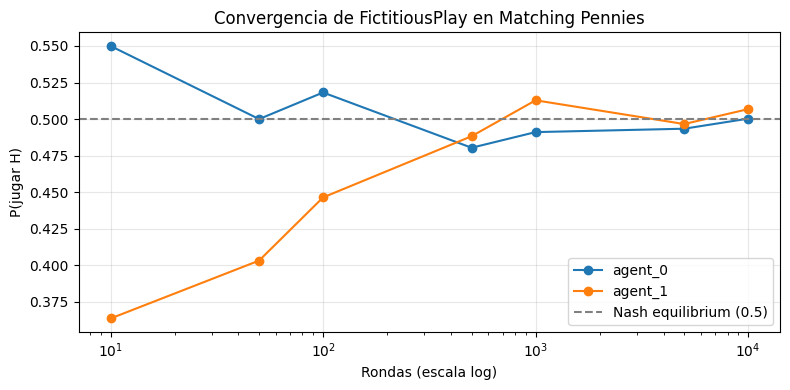

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))

for agent in g.agents:
    ax.plot(checkpoints, history[agent], marker='o', label=agent)

ax.axhline(0.5, color='gray', linestyle='--', label='Nash equilibrium (0.5)')
ax.set_xscale('log')
ax.set_xlabel('Rondas (escala log)')
ax.set_ylabel('P(jugar H)')
ax.set_title('Convergencia de FictitiousPlay en Matching Pennies')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()